In [363]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [364]:
cal = pd.read_csv('data\calories.csv')
ers = pd.read_csv('data\exercise.csv')

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\e'
<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\e'
C:\Users\namde\AppData\Local\Temp\ipykernel_11928\1983537053.py:1: SyntaxWarning: invalid escape sequence '\c'
  cal = pd.read_csv('data\calories.csv')
C:\Users\namde\AppData\Local\Temp\ipykernel_11928\1983537053.py:2: SyntaxWarning: invalid escape sequence '\e'
  ers = pd.read_csv('data\exercise.csv')


In [365]:
cal.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [366]:
ers.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [367]:
print(cal.shape)
print(ers.shape)

(15000, 2)
(15000, 8)


In [368]:
ers.describe().round(1)

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
count,15000.0,15000.0,15000.0,15000.0,15000.0,15000.0,15000.0
mean,14977358.5,42.8,174.5,75.0,15.5,95.5,40.0
std,2872851.5,17.0,14.3,15.0,8.3,9.6,0.8
min,10001159.0,20.0,123.0,36.0,1.0,67.0,37.1
25%,12474190.8,28.0,164.0,63.0,8.0,88.0,39.6
50%,14997285.0,39.0,175.0,74.0,16.0,96.0,40.2
75%,17449278.8,56.0,185.0,87.0,23.0,103.0,40.6
max,19999647.0,79.0,222.0,132.0,30.0,128.0,41.5


In [369]:
df = ers.merge(cal)
df

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...,...
14995,15644082,female,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,female,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,female,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,male,78,193.0,97.0,2.0,84.0,38.3,11.0


# **EDA**

## Univariate Analysis

Text(0, 0.5, 'Count')

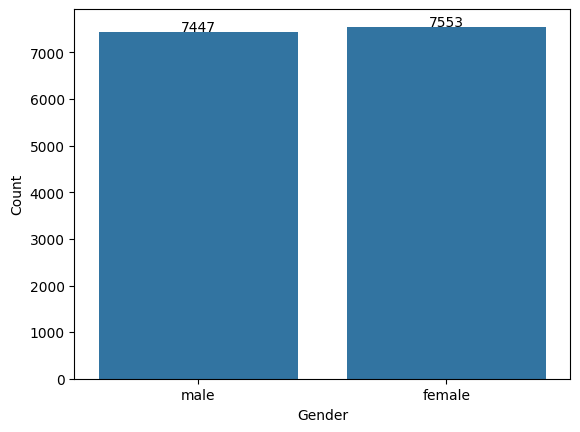

In [370]:
ax = sns.countplot(x='Gender', data=df)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, height + 10, int(height), ha='center')

ax.set_ylabel('Count')

## ----------Insight----------
## Gender of male female is likely to be same

<Axes: xlabel='Age', ylabel='Count'>

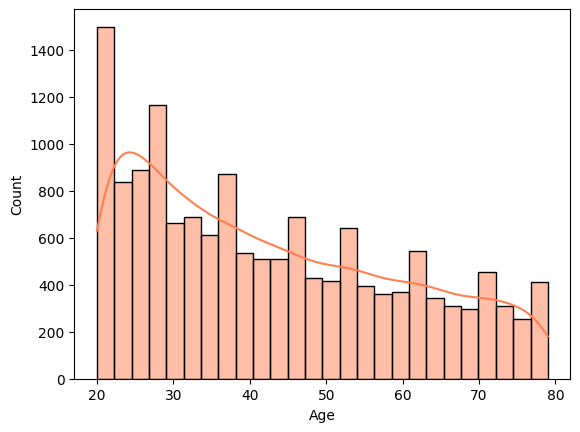

In [371]:
sns.histplot(df['Age'] ,kde=True, color='coral')

## ----------Insight----------
## The Number of youth people is higher than Old peoples

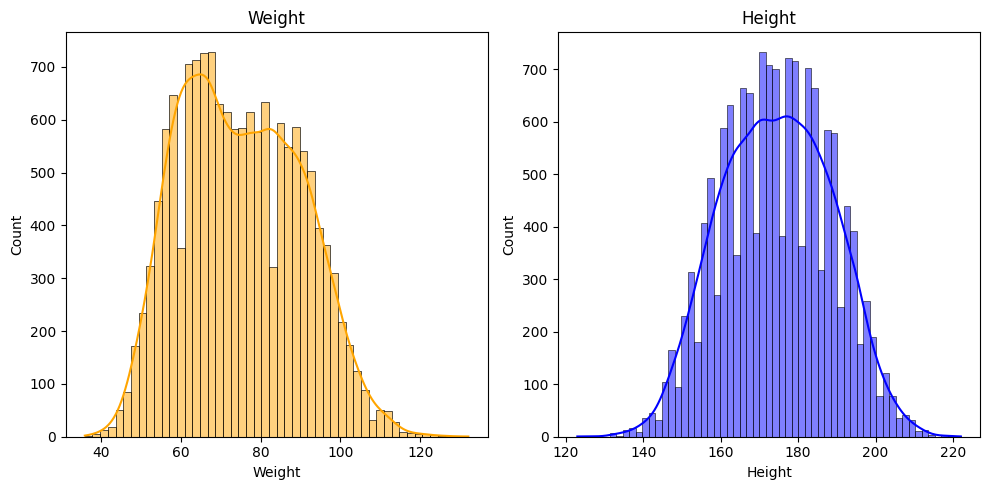

In [372]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.histplot(df['Weight'], kde=True, color='orange')
plt.title("Weight")

plt.subplot(1,2,2)
sns.histplot(df['Height'], kde=True, color='blue')
plt.title("Height")

plt.tight_layout()
plt.show()

## ----------Insight----------
## Weight and Height forms almost a bell curve which shows that their median and mean would be nearby

In [373]:
print('Mean of Height', df['Weight'].mean().round(2))
print('Median of Height', df['Weight'].median().round(2))
print("Mean of Height", df['Height'].mean().round(2))
print("Median of Height", df['Height'].median().round(2))

Mean of Height 74.97
Median of Height 74.0
Mean of Height 174.47
Median of Height 175.0


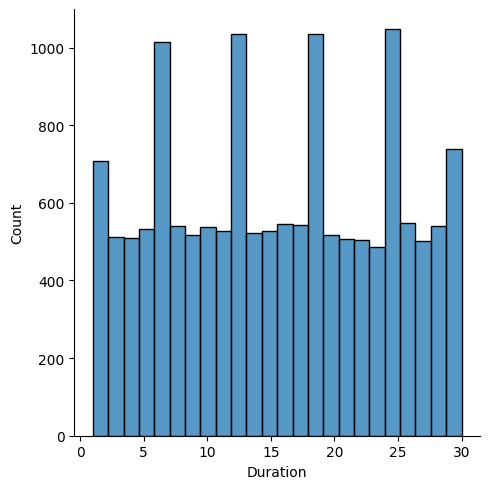

In [374]:
sns.displot(df['Duration'])

<Axes: xlabel='Calories', ylabel='Count'>

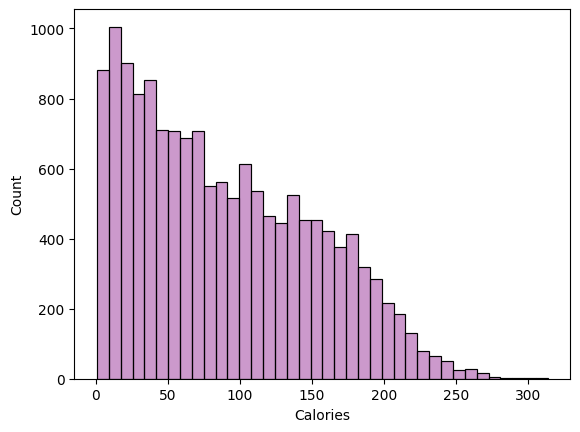

In [375]:
sns.histplot(df['Calories'], color='purple', alpha=0.4)

## ----------Insight----------
## Calories count significantly goes down as it increases

## Bivariate Analysis

<Axes: xlabel='Age', ylabel='Height'>

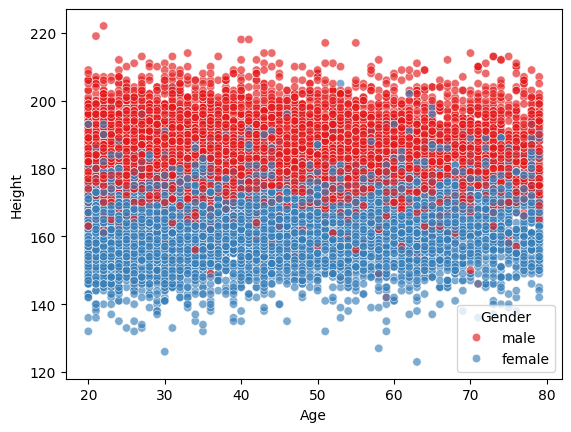

In [376]:
sns.scatterplot(y='Height', x='Age', data=df, hue='Gender', palette='Set1', alpha=0.65)

## ----------Insight----------
## It can be clearly seen that the Male are likely to be taller than women

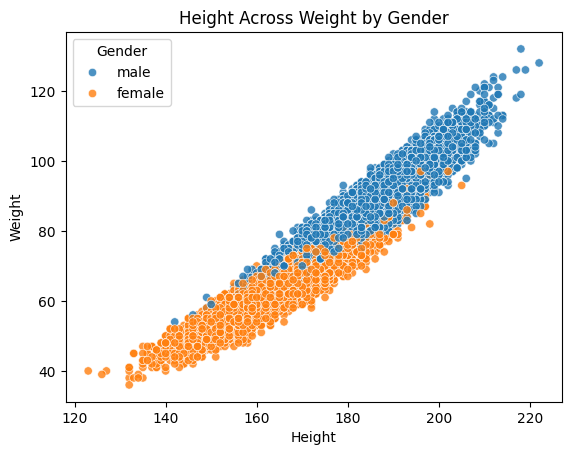

In [377]:
sns.scatterplot(y='Weight', x='Height', data=df, color='green', alpha=0.8, hue='Gender')
plt.title("Height Across Weight by Gender")
plt.show()

## ----------Insight----------
## Weight increase as the height increase and The Male Height/weight is more than Females

In [378]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


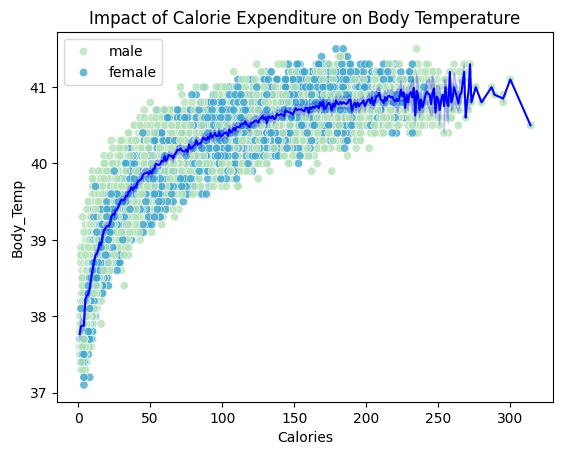

In [379]:
sns.scatterplot(y='Body_Temp', x='Calories', data=df, color='green', alpha=0.8, hue='Gender', palette='GnBu')
sns.lineplot(y='Body_Temp', x='Calories', data=df, color='blue')
plt.title("Impact of Calorie Expenditure on Body Temperature")
plt.show()

## ----------Insight----------
## The more you exercise, the hotter your body gets but only up to a point, after burning around 150 calories, 
## your body temperature stops rising and stays steady near 41°C no matter how much more you push

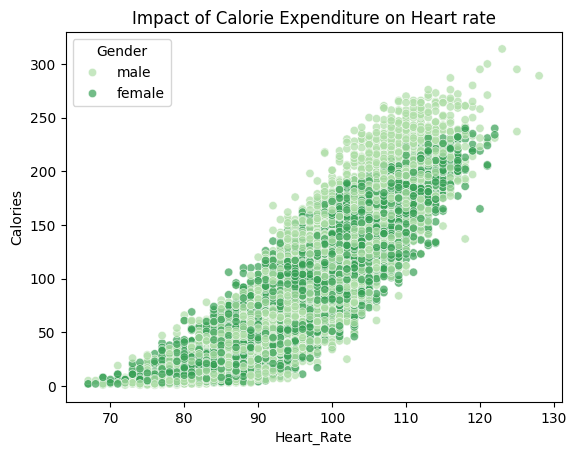

In [380]:
sns.scatterplot(y='Calories', x='Heart_Rate', data=df, alpha=0.7, color='green', hue='Gender', palette='Greens')
plt.title("Impact of Calorie Expenditure on Heart rate")
plt.show()

## ----------Insight----------
## The faster your heart beats during exercise, the more calories you burn and this holds true equally for both men and women.

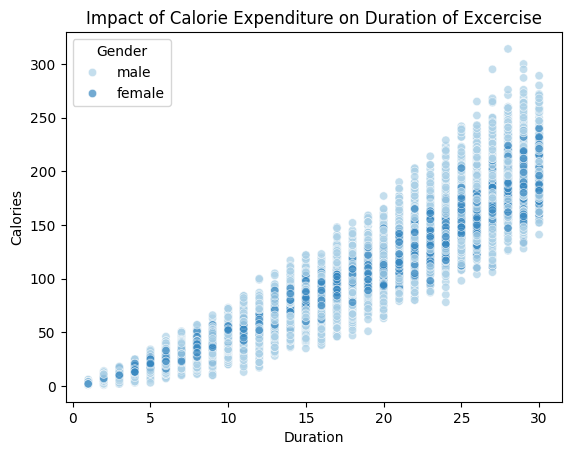

In [381]:
sns.scatterplot(y='Calories', x='Duration', data=df, alpha=0.7, color='green', hue='Gender', palette='Blues')
plt.title("Impact of Calorie Expenditure on Duration of Excercise")
plt.show()

## ----------Insight----------
## A linear relation can be seen in this plot describes that the Calories burn highly depends upon the Duration of Excercise 

<Axes: xlabel='Duration', ylabel='Heart_Rate'>

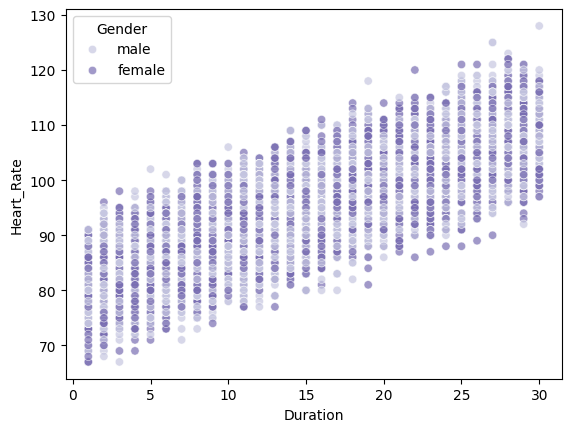

In [382]:
sns.scatterplot(y='Heart_Rate', x='Duration', data=df, alpha=0.7, color='green', hue='Gender', palette='Purples')

## ----------Insight----------
## Same here can be seen that the Heart rate increases as the Duration of Excercise increases

<Axes: xlabel='Body_Temp', ylabel='Heart_Rate'>

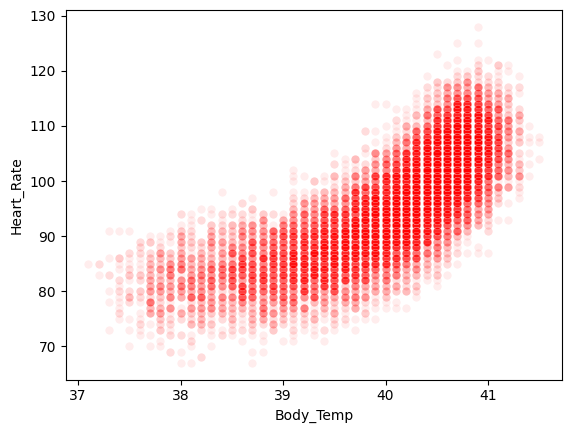

In [383]:
sns.scatterplot(y='Heart_Rate', x='Body_Temp', data=df, alpha=0.07, color='Red')

## ----------Insight----------
## The Heart rate grows linearly till the body reaches 39 degree celsius then it grows rapidly after that 39 degree C 

<Axes: xlabel='Age', ylabel='Calories'>

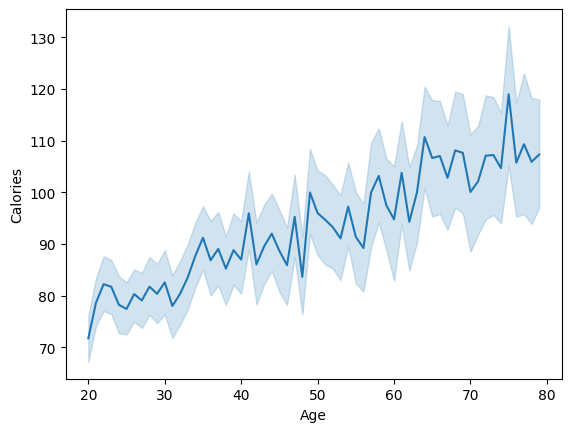

In [384]:
sns.lineplot(x = df['Age'],y = df['Calories'])

## ----------Insight----------
## Older people burn more calories during exercise than younger people, but the results also become more unpredictable with age as the Data shows many ups and downs

<Axes: >

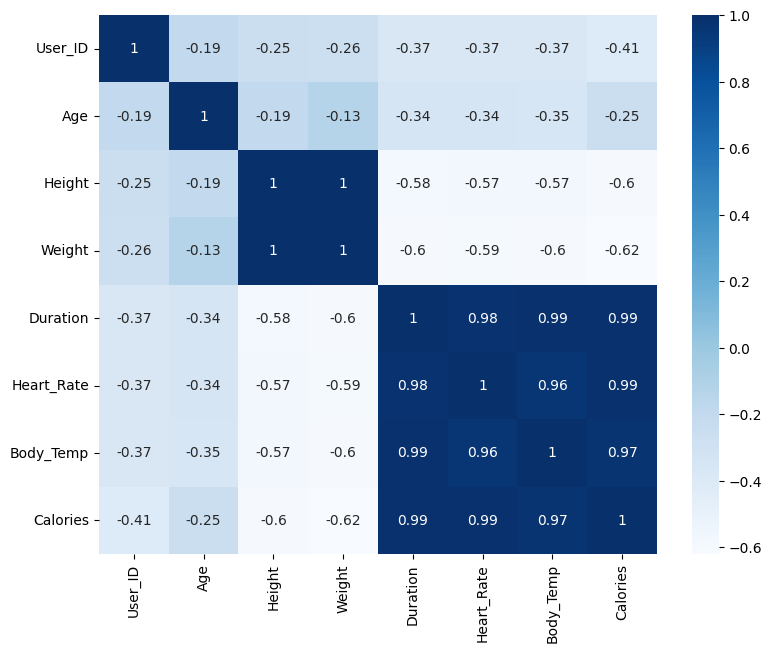

In [385]:
corr = df.corr(numeric_only=True).corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr.round(2),annot=True, cmap='Blues')

In [386]:
df['Gender'].value_counts()

Gender
female    7553
male      7447
Name: count, dtype: int64

In [387]:
df['Gender'] = df['Gender'].map({'male':0, 'female':1})

In [388]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  int64  
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 1.0 MB


In [389]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0


# **Modeling**

## Splitting

In [390]:
X = df.copy()
X = X.drop(columns=['User_ID','Calories'])

In [391]:
y = df.copy()
y = y['Calories']

In [392]:
X.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,0,68,190.0,94.0,29.0,105.0,40.8
1,1,20,166.0,60.0,14.0,94.0,40.3
2,0,69,179.0,79.0,5.0,88.0,38.7
3,1,34,179.0,71.0,13.0,100.0,40.5
4,1,27,154.0,58.0,10.0,81.0,39.8


In [393]:
y

0        231.0
1         66.0
2         26.0
3         71.0
4         35.0
         ...  
14995     45.0
14996     23.0
14997     75.0
14998     11.0
14999     98.0
Name: Calories, Length: 15000, dtype: float64

In [394]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [395]:
X_train.shape

(12000, 7)

In [396]:
X_test.shape

(3000, 7)

## Model training

In [397]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import r2_score,mean_squared_error

In [398]:
models = {
    'LinearRegression':LinearRegression(),
    'RandomForestRegressor':RandomForestRegressor(),
    'DecisionTreeRegressor':DecisionTreeRegressor(),
    'XGBRegressor':XGBRegressor()
}

In [400]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    score_r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    print(f'{name} \nr2_score: {score_r2} \nMSE: {mse}\n')

LinearRegression 
r2_score: 0.9672937151257295 
MSE: 131.99574575081684

RandomForestRegressor 
r2_score: 0.9982656865517844 
MSE: 6.999327433333335

DecisionTreeRegressor 
r2_score: 0.9930959432642085 
MSE: 27.863333333333333

XGBRegressor 
r2_score: 0.9988678909361673 
MSE: 4.568956111227719



In [401]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    print(f"{name}")
    print(f"CV R2 Scores: {scores.round(4)}")
    print(f"Mean R2: {scores.mean().round(4)}")
    print(f"Std Dev: {scores.std().round(4)}\n")

LinearRegression
CV R2 Scores: [0.9663 0.966  0.9681 0.9678 0.967 ]
Mean R2: 0.967
Std Dev: 0.0008

RandomForestRegressor
CV R2 Scores: [0.9976 0.9977 0.9972 0.9976 0.9975]
Mean R2: 0.9975
Std Dev: 0.0002

DecisionTreeRegressor
CV R2 Scores: [0.992  0.9914 0.9913 0.9923 0.9921]
Mean R2: 0.9918
Std Dev: 0.0004

XGBRegressor
CV R2 Scores: [0.9987 0.9988 0.9986 0.9985 0.9986]
Mean R2: 0.9986
Std Dev: 0.0001

